# Phase 2 — Finnish dataset acquisition and exploration

This notebook documents the first inspection of the Universal Dependencies Finnish-TDT and Finnish-FTB treebanks. It is intentionally limited to acquisition, structure inspection, and descriptive statistics. It does **not** create a processed dataset, synthetic learner errors, train/validation/test splits, or a machine-learning model.

The notebook reads files from `data/raw/` and keeps all derived tables in memory. No raw file is written or transformed.

## Dataset provenance and licensing

| Dataset | Source repository | Role in this project | License in the source repository |
|---|---|---|---|
| UD Finnish-TDT | [UniversalDependencies/UD_Finnish-TDT](https://github.com/UniversalDependencies/UD_Finnish-TDT) | Broad-coverage, correctly annotated Finnish for linguistic analysis and later controlled transformations | CC BY-SA 4.0 |
| UD Finnish-FTB | [UniversalDependencies/UD_Finnish-FTB](https://github.com/UniversalDependencies/UD_Finnish-FTB) | Grammar-example oriented Finnish from FinnTreeBank 1 / VISK | CC BY 4.0 (the repository also offers LGPLv3+ as an alternative) |

The repositories were acquired on 2026-09-10 with a depth-1 clone. The checked-out commits are `bfaae13719f249573d940edda6a0d7aa8eec620f` (TDT) and `2dd197c1f7c4b9b6d69be1e3f826162a4443af96` (FTB). Each raw directory retains the upstream README and LICENSE files. TDT contains text from multiple original sources, so its LICENSE.txt must be consulted before redistributing excerpts; FTB identifies VISK and FIN-CLARIN as upstream sources. For academic attribution, follow the TDT README citations (Haverinen et al., 2014; Pyysalo et al., 2015) and the FTB README source acknowledgements.

## CoNLL-U fields used here

Each syntactic row has ten tab-separated columns: `ID`, `FORM`, `LEMMA`, `UPOS`, `XPOS`, `FEATS`, `HEAD`, `DEPREL`, `DEPS`, and `MISC`. This notebook retains all ten columns, while the requested fields have these later uses:

- **ID** — token position. Integer IDs are syntactic words; ranges such as `1-2` are multiword-token rows and dotted IDs such as `3.1` are empty nodes. Keep the distinction for token counts and alignment.
- **FORM** — surface spelling. It is the main text input for later normalization, sentence examples, and error transformations.
- **LEMMA** — dictionary/base form. It supports morphology-oriented grouping and can provide lexical features without conflating inflected forms.
- **UPOS** — universal part of speech. It is useful for distribution checks and compact ML features (for example, a verb versus a noun).
- **XPOS** — Finnish/treebank-specific POS tag. It preserves finer-grained source information that can be useful when Finnish-specific distinctions matter.
- **FEATS** — pipe-separated morphological key/value pairs such as `Case=Ill|Number=Sing` or `Person=1`. This is the most direct source for later case, number, person, tense, mood, and voice analysis.
- **HEAD** — syntactic head ID. It supports dependency-aware features and checks that transformations do not accidentally break a sentence's structure.
- **DEPREL** — dependency relation to the head (for example, `nsubj`, `obj`, `obl`). It can support agreement/case reasoning and later structured ML features.

An underscore (`_`) means that a value is not annotated for that row; it is not necessarily a malformed record. The parser below reports underscores and malformed column counts separately.

In [1]:
from collections import Counter
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    # IPython's OutStream has no reconfigure method; VS Code still renders UTF-8.
    pass

# Make the notebook work both from the repository root and when VS Code
# starts the kernel with notebooks/ as the current directory.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_ROOT = PROJECT_ROOT / "data" / "raw"
assert RAW_ROOT.exists(), f"Raw-data directory not found: {RAW_ROOT}"

DATASETS = {
    "TDT": RAW_ROOT / "finnish_tdt",
    "FTB": RAW_ROOT / "finnish_ftb",
}
FIELD_NAMES = ["ID", "FORM", "LEMMA", "UPOS", "XPOS", "FEATS", "HEAD", "DEPREL", "DEPS", "MISC"]
WORD_ID = re.compile(r"^\d+$")
MWT_ID = re.compile(r"^\d+-\d+$")
EMPTY_ID = re.compile(r"^\d+\.\d+$")

def parse_features(value: str) -> dict:
    if not value or value == "_":
        return {}
    parsed = {}
    for item in value.split("|"):
        if "=" in item:
            key, feature_value = item.split("=", 1)
            parsed[key] = feature_value
    return parsed
print(f"Project root: {PROJECT_ROOT}")
print("Raw dataset directories:", {name: str(path) for name, path in DATASETS.items()})

Project root: C:\Users\leanh\OneDrive\Desktop\code\finnish_learning_assistant
Raw dataset directories: {'TDT': 'C:\\Users\\leanh\\OneDrive\\Desktop\\code\\finnish_learning_assistant\\data\\raw\\finnish_tdt', 'FTB': 'C:\\Users\\leanh\\OneDrive\\Desktop\\code\\finnish_learning_assistant\\data\\raw\\finnish_ftb'}


In [2]:
def parse_conllu_file(path: Path, dataset: str, split: str):
    """Parse one CoNLL-U file without modifying it."""
    sentences = []
    tokens = []
    malformed_rows = []
    comments = []
    rows = []

    def finish_sentence():
        if not rows:
            comments.clear()
            return
        sent_id = next((c.split("=", 1)[1].strip() for c in comments if c.startswith("# sent_id") and "=" in c), None)
        text = next((c.split("=", 1)[1].strip() for c in comments if c.startswith("# text") and "=" in c), None)
        if not text:
            text = " ".join(r["FORM"] for r in rows if WORD_ID.match(r["ID"]))
        sentence_number = len(sentences) + 1
        sentence_record = {
            "dataset": dataset,
            "split": split,
            "file": path.name,
            "sentence_number": sentence_number,
            "sent_id": sent_id or f"{dataset.lower()}-{split}-{sentence_number}",
            "text": text,
            "row_count": len(rows),
            "word_count": sum(bool(WORD_ID.match(r["ID"])) for r in rows),
            "multiword_token_count": sum(bool(MWT_ID.match(r["ID"])) for r in rows),
            "empty_node_count": sum(bool(EMPTY_ID.match(r["ID"])) for r in rows),
        }
        sentences.append(sentence_record)
        for row_index, row in enumerate(rows, start=1):
            token = {"dataset": dataset, "split": split, "file": path.name, "sentence_number": sentence_number, "sent_id": sentence_record["sent_id"], "row_index": row_index}
            token.update(row)
            tokens.append(token)
        comments.clear()
        rows.clear()

    with path.open(encoding="utf-8") as handle:
        for line_number, raw_line in enumerate(handle, start=1):
            line = raw_line.rstrip("\n")
            if not line.strip():
                finish_sentence()
                continue
            if line.startswith("#"):
                comments.append(line)
                continue
            fields = line.split("\t")
            if len(fields) != len(FIELD_NAMES):
                malformed_rows.append({"file": path.name, "line_number": line_number, "column_count": len(fields), "line": line})
                continue
            rows.append(dict(zip(FIELD_NAMES, fields)))
    finish_sentence()
    return sentences, tokens, malformed_rows

def load_treebank(dataset: str, directory: Path):
    all_sentences, all_tokens, all_malformed = [], [], []
    conllu_files = sorted(directory.glob("*.conllu"))
    assert conllu_files, f"No CoNLL-U files found in {directory}"
    for path in conllu_files:
        split_match = re.search(r"-ud-(train|dev|test)\.conllu$", path.name)
        split = split_match.group(1) if split_match else path.stem
        sentences, tokens, malformed = parse_conllu_file(path, dataset, split)
        all_sentences.extend(sentences)
        all_tokens.extend(tokens)
        all_malformed.extend(malformed)
    return pd.DataFrame(all_sentences), pd.DataFrame(all_tokens), pd.DataFrame(all_malformed)

loaded = {}
for dataset, directory in DATASETS.items():
    sentences, tokens, malformed = load_treebank(dataset, directory)
    loaded[dataset] = {"sentences": sentences, "tokens": tokens, "malformed": malformed}
    print(f"{dataset}: {len(sentences):,} sentences, {len(tokens):,} CoNLL-U rows, {len(malformed):,} malformed rows")
    print("  files:", sorted(tokens["file"].unique()))

TDT: 15,136 sentences, 202,698 CoNLL-U rows, 0 malformed rows
  files: ['fi_tdt-ud-dev.conllu', 'fi_tdt-ud-test.conllu', 'fi_tdt-ud-train.conllu']


FTB: 18,723 sentences, 159,936 CoNLL-U rows, 0 malformed rows
  files: ['fi_ftb-ud-dev.conllu', 'fi_ftb-ud-test.conllu', 'fi_ftb-ud-train.conllu']


## Structure and coverage

The sentence count is the number of CoNLL-U sentence blocks. `word_tokens` counts integer IDs only, which is the standard token count for syntactic words; multiword-token ranges and empty nodes are reported separately. `feature_value_occurrences` counts annotated FEATS key/value occurrences across word rows, not distinct feature types. The source train/dev/test labels are descriptive metadata from the repositories, not a new project split.

In [3]:
summary_rows = []
for dataset, bundle in loaded.items():
    sentences = bundle["sentences"]
    tokens = bundle["tokens"]
    summary_rows.append({
        "dataset": dataset,
        "sentences": len(sentences),
        "word_tokens": int(sentences["word_count"].sum()),
        "multiword_token_rows": int(sentences["multiword_token_count"].sum()),
        "empty_node_rows": int(sentences["empty_node_count"].sum()),
        "avg_words_per_sentence": round(sentences["word_count"].mean(), 2),
        "unique_lemmas": int(tokens.loc[tokens["ID"].str.match(WORD_ID), "LEMMA"].nunique()),
        "upos_types": int(tokens.loc[tokens["ID"].str.match(WORD_ID), "UPOS"].nunique()),
        "feature_value_occurrences": int(sum(len(parse_features(value)) for value in tokens.loc[tokens["ID"].str.match(WORD_ID), "FEATS"])) ,
    })
summary = pd.DataFrame(summary_rows).set_index("dataset")
summary

,sentences,word_tokens,multiword_token_rows,empty_node_rows,avg_words_per_sentence,unique_lemmas,upos_types,feature_value_occurrences
dataset,,,,,,,,
TDT,15136,202193,244,261,13.36,26288,15,464507
FTB,18723,159625,311,0,8.53,21513,17,380607


**Metadata check.** The FTB README's human-readable summary says `Word count: 159612`, while its machine-readable `stats.xml` and this parser both report 159,625 syntactic words (159,314 surface tokens plus 311 fused rows). The parser and `stats.xml` agree, so Phase 3 should use the checked-out CoNLL-U files and record this discrepancy rather than silently copying the stale README total.

## Missing values and parser quality

In CoNLL-U, `_` is a valid explicit absence of an annotation. We therefore report it as a missing annotation but do not drop the row. FORM and ID should be populated for ordinary word rows; HEAD and DEPS may legitimately be `_` in some enhanced or non-standard analyses.

In [4]:
def missing_report(tokens: pd.DataFrame) -> pd.DataFrame:
    word_rows = tokens[tokens["ID"].str.match(WORD_ID)].copy()
    rows = []
    for field in FIELD_NAMES:
        missing = word_rows[field].isna() | word_rows[field].eq("") | word_rows[field].eq("_")
        rows.append({"field": field, "missing_rows": int(missing.sum()), "missing_percent": round(100 * missing.mean(), 3)})
    return pd.DataFrame(rows).set_index("field")

for dataset, bundle in loaded.items():
    print(f"{dataset} missing-annotation report (integer word IDs)")
    print(missing_report(bundle["tokens"]))
    print(f"Malformed rows: {len(bundle['malformed'])}")

TDT missing-annotation report (integer word IDs)


        missing_rows  missing_percent
field                                
ID                 0            0.000
FORM               0            0.000
LEMMA             23            0.011
UPOS               0            0.000
XPOS               0            0.000
FEATS          56002           27.697
HEAD               0            0.000
DEPREL             0            0.000
DEPS               0            0.000
MISC          173340           85.730
Malformed rows: 0
FTB missing-annotation report (integer word IDs)


        missing_rows  missing_percent
field                                
ID                 0            0.000
FORM               0            0.000
LEMMA              9            0.006
UPOS               0            0.000
XPOS               7            0.004
FEATS          45408           28.447
HEAD               0            0.000
DEPREL             0            0.000
DEPS          159625          100.000
MISC          146465           91.756
Malformed rows: 0


## UPOS distribution

UPOS gives a comparable, language-independent view of the two resources. TDT is broad-coverage text, while FTB is grammar-example oriented, so differences in the relative mix of verbs, nouns, pronouns, and punctuation are expected.

In [5]:
upos_counts = {}
for dataset, bundle in loaded.items():
    words = bundle["tokens"][bundle["tokens"]["ID"].str.match(WORD_ID)]
    upos_counts[dataset] = words["UPOS"].value_counts()
upos = pd.DataFrame(upos_counts).fillna(0).astype(int)
upos["total"] = upos.sum(axis=1)
upos = upos.sort_values("total", ascending=False)
upos

,TDT,FTB,total
UPOS,,,
NOUN,56450,37041,93491
VERB,27341,27197,54538
PUNCT,29606,22565,52171
ADV,15620,13323,28943
ADJ,14289,10488,24777
PRON,13475,11085,24560
AUX,12110,10535,22645
PROPN,12122,6772,18894
CCONJ,8319,4804,13123


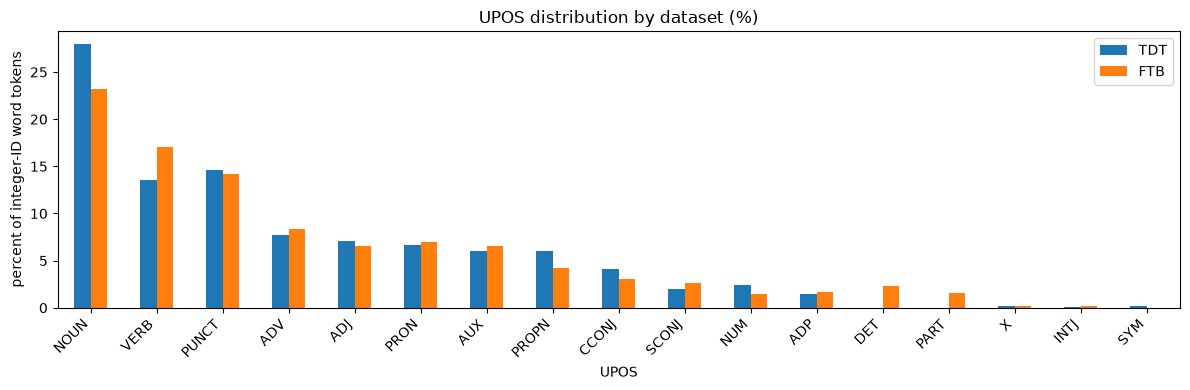

In [6]:
upos_percent = upos.drop(columns="total").div(summary["word_tokens"], axis=1).mul(100).round(2)
upos_percent.plot(kind="bar", figsize=(12, 4), title="UPOS distribution by dataset (%)")
plt.ylabel("percent of integer-ID word tokens")
plt.xlabel("UPOS")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Finnish morphological features

The `FEATS` column is a compact map of grammatical properties. For this project, the highest-value keys to inspect first are `Case`, `Number`, `Person`, `Tense`, `Mood`, `VerbForm`, `Voice`, `Degree`, `PronType`, and `Polarity`. Case/number/person are especially relevant to later case-error, inflection, agreement, plural, and verb-conjugation transformations.

In [7]:
selected_keys = ["Case", "Number", "Person", "Tense", "Mood", "VerbForm", "Voice", "Degree", "PronType", "Polarity"]
feature_rows = []
for dataset, bundle in loaded.items():
    words = bundle["tokens"][bundle["tokens"]["ID"].str.match(WORD_ID)]
    pair_counts = Counter()
    for value in words["FEATS"]:
        for key, feature_value in parse_features(value).items():
            if key in selected_keys:
                pair_counts[f"{key}={feature_value}"] += 1
    for pair, count in pair_counts.most_common():
        key = pair.split("=", 1)[0]
        feature_rows.append({"dataset": dataset, "feature": pair, "count": count, "key": key})
feature_counts = pd.DataFrame(feature_rows)
feature_counts.sort_values(["dataset", "count"], ascending=[True, False]).groupby("dataset").head(15)

,dataset,feature,count,key
42,FTB,Number=Sing,78985,Number
43,FTB,Voice=Act,34031,Voice
44,FTB,Case=Nom,29639,Case
45,FTB,VerbForm=Fin,27122,VerbForm
46,FTB,Mood=Ind,24605,Mood
47,FTB,Person=3,20032,Person
48,FTB,Number=Plur,18174,Number
49,FTB,Tense=Pres,14042,Tense
50,FTB,Case=Gen,13777,Case
51,FTB,Case=Par,12499,Case


In [8]:
feature_key_counts = feature_counts.groupby(["dataset", "key"])["count"].sum().unstack(0).fillna(0).astype(int)
feature_key_counts = feature_key_counts.reindex(selected_keys).dropna(how="all")
feature_key_counts

dataset,FTB,TDT
key,,
Case,80529,106579
Number,97159,131889
Person,27603,24778
Tense,21587,21613
Mood,27122,23512
VerbForm,37732,39451
Voice,37429,37882
Degree,1383,12673
PronType,17304,13209


## Representative Finnish sentences

The examples below select one sentence near each treebank's median sentence length from every upstream split. This avoids presenting one-token fragments or extreme length outliers as typical Finnish. The `# text` metadata preserves the source's original spacing and punctuation, while token rows expose the annotation needed for later analysis.

In [9]:
example_rows = []
for dataset, bundle in loaded.items():
    sentences = bundle["sentences"]
    typical_word_count = int(sentences["word_count"].median())
    for split in ("train", "dev", "test"):
        candidates = sentences[
            sentences["split"].eq(split)
            & sentences["word_count"].between(max(3, typical_word_count - 1), typical_word_count + 1)
            & sentences["text"].str.endswith((".", "?", "!"))
        ].sort_values("sent_id").reset_index(drop=True)
        row = candidates.iloc[len(candidates) // 2]
        example_rows.append({"dataset": dataset, "split": split, "sent_id": row["sent_id"], "word_count": row["word_count"], "text": row["text"]})
pd.DataFrame(example_rows)

,dataset,split,sent_id,word_count,text
0,TDT,train,j029.18,11,Alakomitean tehtävistä ja työjärjestyksestä on keskusteltu epävirallisesti Tunisian viranomaisten kanssa.
1,TDT,dev,h1034.8,12,"Näyttelymme haluaa puolustaa kaikkea sitä, mikä näin ymmärrettynä ilmentää naisellisuutta."
2,TDT,test,j001.30,13,Eläinkuljettajien olisi näin ollen toimittava vastuullisemmin ja avoimemmin asemansa ja toimiensa osalta.
3,FTB,train,me5gx-11900,6,Minä en muistanut ostaa leipää .
4,FTB,dev,nc89r-15243,8,Turvavyöt on pidettävä kiinnitettyinä koko lennon ajan .
5,FTB,test,njfgw-16805,7,Pitikö sitä taas nukkua viimeiseen asti !


## Basic TDT–FTB comparison

TDT and FTB are complementary rather than interchangeable. TDT provides broad-coverage, multi-genre text and richer dependency context; FTB contributes a large set of manually revised grammar examples. Both are correctly annotated linguistic resources, not authentic learner-error corpora. Phase 3 should consume their sentence text plus token-level lemma, POS, morphology, and dependency annotations while preserving `dataset`, `split`, `file`, and `sent_id` provenance.

In [10]:
comparison = summary[["sentences", "word_tokens", "avg_words_per_sentence", "unique_lemmas", "upos_types", "feature_value_occurrences"]].copy()
comparison["text_genre_note"] = ["broad coverage: news, wiki, blog, legal, fiction, grammar examples", "grammar examples from FinnTreeBank 1 / VISK"]
comparison

,sentences,word_tokens,avg_words_per_sentence,unique_lemmas,upos_types,feature_value_occurrences,text_genre_note
dataset,,,,,,,
TDT,15136,202193,13.36,26288,15,464507,"broad coverage: news, wiki, blog, legal, ficti..."
FTB,18723,159625,8.53,21513,17,380607,grammar examples from FinnTreeBank 1 / VISK


## Phase 2 conclusions and hand-off

- Keep the downloaded repositories and their upstream README/LICENSE files under `data/raw/`; do not edit the CoNLL-U files.
- Use integer-ID rows for ordinary word-level counts, and preserve multiword-token and empty-node rows for alignment-sensitive processing.
- Preserve sentence IDs and source dataset/split metadata so future derived examples can be traced back and grouped to avoid leakage.
- Parse `FEATS` into key/value maps in preprocessing; begin with Case, Number, Person, Tense, Mood, VerbForm, Voice, Degree, PronType, and Polarity.
- Phase 3 should consume the raw sentence/token annotations and produce a separate processed representation. It should decide normalization and filtering rules; this notebook deliberately does not do that work.